# AI vs Human Writing Analysis Notebook

## Import libraries

In [1]:
import pandas as pd
import textstat

## Load dataset

In [2]:
# Make sure your CSV file is in the same folder as the notebook
df = pd.read_csv("ai_vs_human_text.csv")

# Preview dataset
df.head()

,id,text,label,prompt,model,date
0,1,AI-generated content sample 1: This is an exam...,AI-generated,Explain the benefits of deep learning.,ChatGPT,2023-11-25
1,2,AI-generated content sample 2: This is an exam...,AI-generated,Write an article on the future of AI.,Bard,2024-11-15
2,3,Human-written text sample 3: This is an exampl...,Human-written,Editorial on the impact of technology in society.,Human,2024-08-11
3,4,AI-generated content sample 4: This is an exam...,AI-generated,Describe how neural networks work.,Claude,2024-04-27
4,5,Human-written text sample 5: This is an exampl...,Human-written,Personal essay on learning programming.,Human,2024-08-15


## Check dataset structure

In [3]:
df.info()
df['label'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1000 non-null   int64
 1   text    1000 non-null   str  
 2   label   1000 non-null   str  
 3   prompt  1000 non-null   str  
 4   model   1000 non-null   str  
 5   date    1000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 47.0 KB


label
AI-generated     507
Human-written    493
Name: count, dtype: int64

## Define analysis function

In [4]:
def analyze_text(text):
    word_count = len(str(text).split())
    readability = textstat.flesch_reading_ease(str(text))
    
    return word_count, readability

## Apply analysis to dataset

In [5]:
df[['word_count', 'readability']] = df['text'].apply(
    lambda x: pd.Series(analyze_text(x))
)

df.head()

,id,text,label,prompt,model,date,word_count,readability
0,1,AI-generated content sample 1: This is an exam...,AI-generated,Explain the benefits of deep learning.,ChatGPT,2023-11-25,24.0,37.950000
1,2,AI-generated content sample 2: This is an exam...,AI-generated,Write an article on the future of AI.,Bard,2024-11-15,26.0,50.291154
2,3,Human-written text sample 3: This is an exampl...,Human-written,Editorial on the impact of technology in society.,Human,2024-08-11,28.0,33.386429
3,4,AI-generated content sample 4: This is an exam...,AI-generated,Describe how neural networks work.,Claude,2024-04-27,23.0,47.394348
4,5,Human-written text sample 5: This is an exampl...,Human-written,Personal essay on learning programming.,Human,2024-08-15,25.0,46.100000


## Compare AI vs Human writing

In [6]:
results = df.groupby('label')[['word_count', 'readability']].mean()

print("=== Average Comparison ===")
print(results)

=== Average Comparison ===
               word_count  readability
label                                 
AI-generated    24.518738    41.535376
Human-written   25.815416    45.211557


## More detailed statistics

In [7]:
df.groupby('label')[['word_count', 'readability']].describe()

word_count                                                     \
                   count       mean       std   min   25%   50%   75%   max   
label                                                                         
AI-generated       507.0  24.518738  1.135635  23.0  24.0  24.0  26.0  26.0   
Human-written      493.0  25.815416  1.336026  25.0  25.0  25.0  28.0  28.0   

              readability                                             \
                    count       mean       std        min        25%   
label                                                                  
AI-generated        507.0  41.535376  7.094924  25.796000  37.950000   
Human-written       493.0  45.211557  7.627210  33.386429  33.386429   

                                                
                     50%        75%        max  
label                                           
AI-generated   43.716087  47.394348  50.291154  
Human-written  46.100000  52.868000  52.868000

## Compare by model

In [8]:
model_results = df.groupby('model')[['word_count', 'readability']].mean()

print("=== Model Comparison ===")
print(model_results)

=== Model Comparison ===
         word_count  readability
model                           
Bard      24.571429    43.821348
ChatGPT   24.458647    37.658579
Claude    24.644928    44.049846
GPT-4     24.395161    40.830443
Human     25.815416    45.211557


## Simple visualization

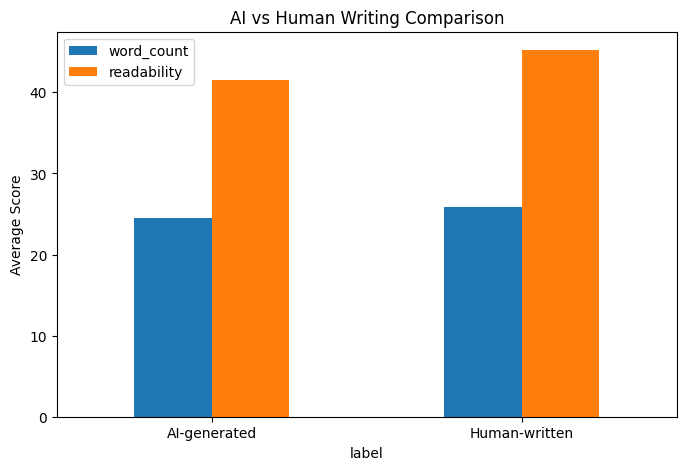

In [9]:
import matplotlib.pyplot as plt

results.plot(kind='bar', figsize=(8,5))
plt.title("AI vs Human Writing Comparison")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

## Save results

In [10]:
df.to_csv("analyzed_results.csv", index=False)
results.to_csv("summary_results.csv")

print("Files saved successfully!")

Files saved successfully!
